In [8]:
!pip install ultralytics opencv-python

In [9]:
#把drive掛載到colab
from google.colab import drive
drive.mount('/content/drive')


import zipfile
import os

#壓縮檔位置，和解壓到哪裡
zip_path = "/content/drive/MyDrive/kitti.zip"
extract_path = "kitti_small"

wanted = [
    "kitti/training/image_2/000000_10.png",
    "kitti/training/image_3/000000_10.png",
    "kitti/training/disp_occ_0/000000_10.png",

    "kitti/training/image_2/000001_10.png",
    "kitti/training/image_3/000001_10.png",
    "kitti/training/disp_occ_0/000001_10.png",
]

#打開zip檔，再逐個解壓圖片
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in wanted:
        zip_ref.extract(file, extract_path)

print("少量圖片解壓完成")

calib_zip_path = "/content/drive/MyDrive/data_scene_flow_calib.zip"
calib_extract_path = "kitti_calib"

with zipfile.ZipFile(calib_zip_path, 'r') as zip_ref:
    zip_ref.extractall(calib_extract_path)

print("calibration 解壓完成")

LEFT_FOLDER = "kitti_small/kitti/training/image_2"
RIGHT_FOLDER = "kitti_small/kitti/training/image_3"
GT_DISP_FOLDER = "kitti_small/kitti/training/disp_occ_0"
CALIB_FOLDER = "kitti_calib/training/calib_cam_to_cam"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
少量圖片解壓完成
calibration 解壓完成


In [10]:
import os

files = os.listdir(LEFT_FOLDER)
print(files[:5])

for root, dirs, files in os.walk("kitti_calib"):
    print(root)
    print(files[:5])
    print("-----")

['000001_10.png', '000000_10.png']
kitti_calib
[]
-----
kitti_calib/testing
[]
-----
kitti_calib/testing/calib_cam_to_cam
['000108.txt', '000132.txt', '000180.txt', '000178.txt', '000116.txt']
-----
kitti_calib/testing/calib_imu_to_velo
['000108.txt', '000132.txt', '000180.txt', '000178.txt', '000116.txt']
-----
kitti_calib/testing/calib_velo_to_cam
['000108.txt', '000132.txt', '000180.txt', '000178.txt', '000116.txt']
-----
kitti_calib/training
[]
-----
kitti_calib/training/calib_cam_to_cam
['000108.txt', '000132.txt', '000180.txt', '000178.txt', '000116.txt']
-----
kitti_calib/training/calib_imu_to_velo
['000108.txt', '000132.txt', '000180.txt', '000178.txt', '000116.txt']
-----
kitti_calib/training/calib_velo_to_cam
['000108.txt', '000132.txt', '000180.txt', '000178.txt', '000116.txt']
-----


目前圖片: 000000_10.png
圖片編號: 000000


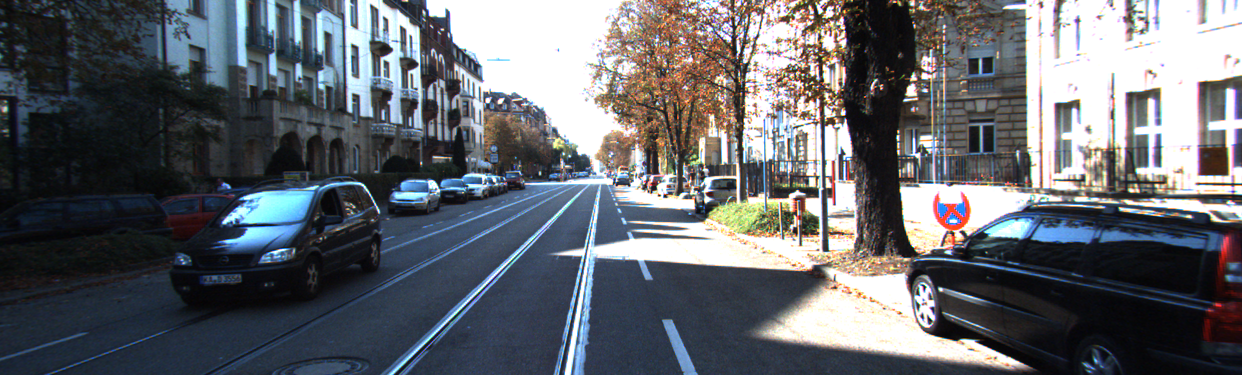

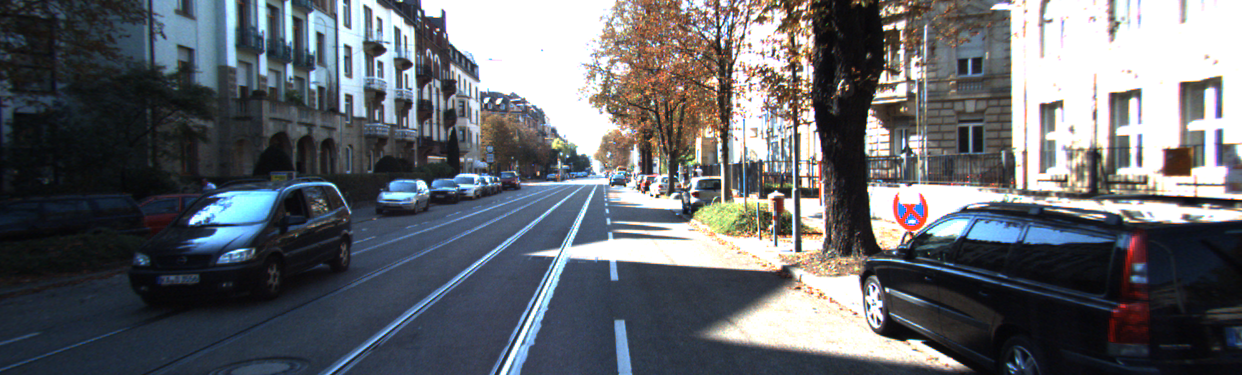

calib_path = kitti_calib/training/calib_cam_to_cam/000000.txt
calib 是否存在: True
目前使用的 calibration: kitti_calib/training/calib_cam_to_cam/000000.txt
FOCAL_LENGTH = 721.5377
BASELINE = 0.5327254279298227


In [4]:
# 讀取影像 + 讀取 calibration
import os
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 只抓 _10.png，避免抓到 _11.png
files = sorted([f for f in os.listdir(LEFT_FOLDER) if f.endswith("_10.png")])

test_file = files[0]
img_id = test_file.replace("_10.png", "")

print("目前圖片:", test_file)
print("圖片編號:", img_id)

# 讀取左右影像
left_img = cv2.imread(f"{LEFT_FOLDER}/{test_file}")
right_img = cv2.imread(f"{RIGHT_FOLDER}/{test_file}")

if left_img is None:
    raise FileNotFoundError(f"讀不到左圖：{LEFT_FOLDER}/{test_file}")

if right_img is None:
    raise FileNotFoundError(f"讀不到右圖：{RIGHT_FOLDER}/{test_file}")

cv2_imshow(left_img)
cv2_imshow(right_img)


# calibration 資料夾
CALIB_FOLDER = "kitti_calib/training/calib_cam_to_cam"

def read_kitti2015_calib(calib_path):
    calib = {}

    with open(calib_path, "r") as f:
        for line in f:
            if ":" not in line:
                continue

            key, value = line.split(":", 1)
            key = key.strip()
            value = value.strip()

            # 跳過空值
            if value == "":
                continue

            # 有些欄位是日期，例如 date: 09-Jan-2012
            # 這種不是數字，不能轉 float，所以跳過
            try:
                calib[key] = np.array([float(x) for x in value.split()])
            except ValueError:
                continue

    P2 = calib["P_rect_02"].reshape(3, 4)
    P3 = calib["P_rect_03"].reshape(3, 4)

    focal_length = P2[0, 0]

    tx2 = -P2[0, 3] / P2[0, 0]
    tx3 = -P3[0, 3] / P3[0, 0]

    baseline = abs(tx3 - tx2)

    return focal_length, baseline


calib_path = f"{CALIB_FOLDER}/{img_id}.txt"

print("calib_path =", calib_path)
print("calib 是否存在:", os.path.exists(calib_path))

if not os.path.exists(calib_path):
    raise FileNotFoundError(f"找不到 calibration 檔案：{calib_path}")

FOCAL_LENGTH, BASELINE = read_kitti2015_calib(calib_path)

print("目前使用的 calibration:", calib_path)
print("FOCAL_LENGTH =", FOCAL_LENGTH)
print("BASELINE =", BASELINE)

===== 視差誤差評估 =====
MAE 平均誤差: 5.45406
Median 中位數誤差: 0.5625
Max 最大誤差: 101.69141


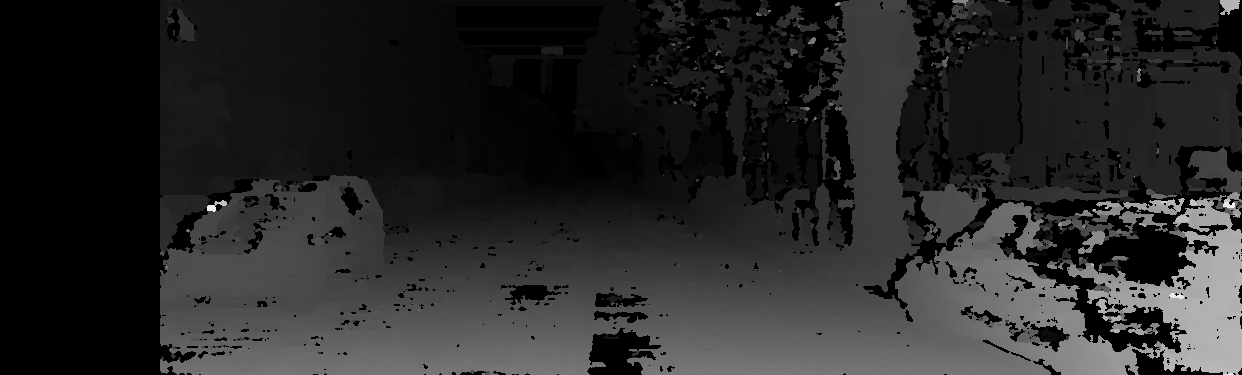

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def compute_disparity(left_img, right_img):
    gray_left = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

    window_size = 5

    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16 * 10,
        blockSize=window_size,

        P1=8 * 1 * window_size ** 2,
        P2=32 * 1 * window_size ** 2,

        disp12MaxDiff=1,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )

    disparity = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

    disparity[disparity < 0] = 0

    return disparity


disparity = compute_disparity(left_img, right_img)

gt_path = f"{GT_DISP_FOLDER}/{test_file}"

gt_disp = cv2.imread(gt_path, cv2.IMREAD_UNCHANGED)

if gt_disp is None:
    print("讀不到官方視差圖:", gt_path)
else:
    gt_disp = gt_disp.astype(np.float32) / 256.0

    valid = gt_disp > 0

    error = np.abs(disparity[valid] - gt_disp[valid])

    print("===== 視差誤差評估 =====")
    print("MAE 平均誤差:", np.mean(error))
    print("Median 中位數誤差:", np.median(error))
    print("Max 最大誤差:", np.max(error))

# 5. 顯示用：轉成 0~255
disp_vis = cv2.normalize(
    disparity,
    None,
    alpha=0,
    beta=255,
    norm_type=cv2.NORM_MINMAX
)

disp_vis = np.uint8(disp_vis)

cv2_imshow(disp_vis)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 224x640 12 cars, 48.0ms
Speed: 10.8ms preprocess, 48.0ms inference, 39.7ms postprocess per image at shape (1, 3, 224, 640)


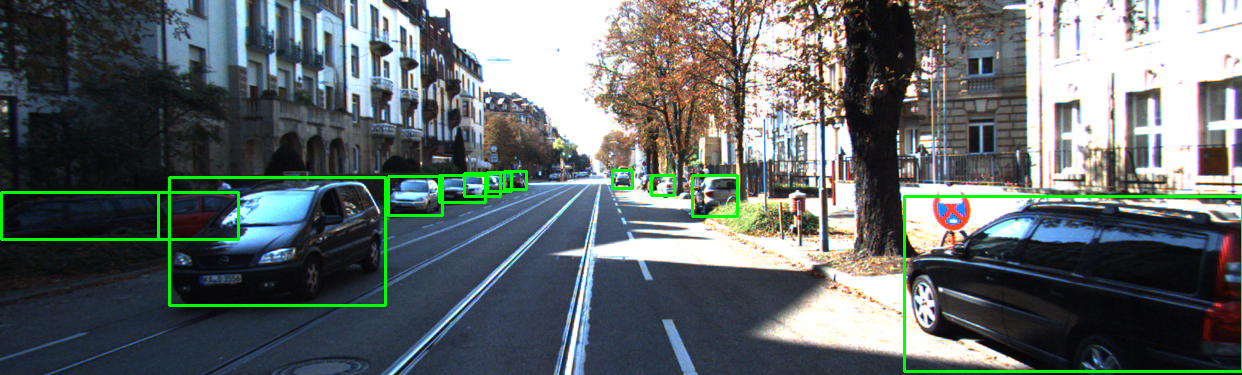

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

detect_img = left_img.copy()

results = model(detect_img)

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(detect_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

cv2_imshow(detect_img)

深度圖完成
有效最小距離: 2.8121188
有效最大距離: 99.19522
有效中位數距離: 15.769497

0: 224x640 12 cars, 10.2ms
Speed: 2.3ms preprocess, 10.2ms inference, 1.9ms postprocess per image at shape (1, 3, 224, 640)


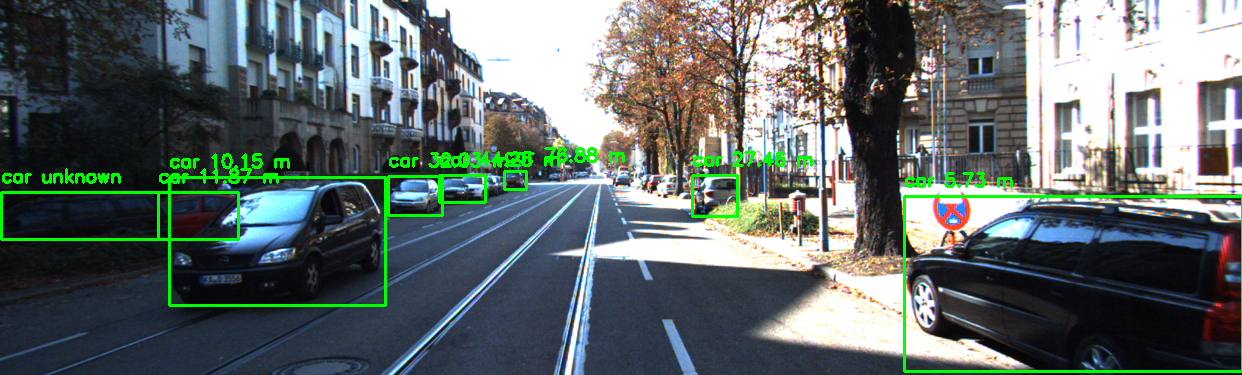

In [7]:
def compute_depth(disparity):
    depth = np.zeros_like(disparity, dtype=np.float32)

    valid = disparity > 0
    depth[valid] = (FOCAL_LENGTH * BASELINE) / disparity[valid]

    return depth


depth_map = compute_depth(disparity)

valid_depth = depth_map[(depth_map > 0) & (depth_map < 100)]

print("深度圖完成")
print("有效最小距離:", np.min(valid_depth))
print("有效最大距離:", np.max(valid_depth))
print("有效中位數距離:", np.median(valid_depth))


def get_distance(depth_map, x1, y1, x2, y2):
    h, w = depth_map.shape

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    # 只取框中間 60% 區域，避免框邊緣混到背景
    box_w = x2 - x1
    box_h = y2 - y1

    cx1 = x1 + int(box_w * 0.2)
    cx2 = x2 - int(box_w * 0.2)
    cy1 = y1 + int(box_h * 0.2)
    cy2 = y2 - int(box_h * 0.2)

    area = depth_map[cy1:cy2, cx1:cx2]

    valid = area[
        (area > 0) &
        (area < 80)
    ]

    if len(valid) == 0:
        return None

    return np.median(valid)


original_img = left_img.copy()
result_img = original_img.copy()

results = model(original_img)

for result in results:
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        label = model.names[cls_id]

        # 只保留車輛相關類別
        if label not in ["car", "truck", "bus", "motorcycle"]:
            continue

        if conf < 0.4:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        distance = get_distance(depth_map, x1, y1, x2, y2)

        cv2.rectangle(result_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        if distance is not None:
            text = f"{label} {distance:.2f} m"
        else:
            text = f"{label} unknown"

        cv2.putText(
            result_img,
            text,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

cv2_imshow(result_img)